In [1]:
using Plots,JLD2,LinearAlgebra

In [2]:
Nx=18
Ny=18
tper=-0.37

tpa=2.0
tNNN=-0.08

α=-1.5
temp=0.09
β=0.15
K=1.0;
KNNN=0.0;
gshear=0.1
trytime_record=1

filling=1.25
#trytime=1

1.25

In [3]:
st=load("test.jld2")
   

Dict{String, Any} with 14 entries:
  "Eelec"          => -2.38429
  "grad"           => [0.000806869, -0.000817728, 0.000849615, -0.0008255, 0.00…
  "spectrum"       => [-4.74159, -4.74159, -4.69709, -4.69709, -4.69709, -4.697…
  "max_record"     => 0.0922869
  "average_record" => 0.0583075
  "record_cal"     => Vector{Any}[[-2.36564, -2.36622, -2.35352, -2.34595, -2.3…
  "orbital_id"     => [1 19 … 289 307; 2 20 … 290 308; … ; 17 35 … 305 323; 18 …
  "phonon_id"      => [1 19 … 289 307; 2 20 … 290 308; … ; 17 35 … 305 323; 18 …
  "phonon_coor"    => [0.0442178, -0.00242028, -0.040206, 0.0623036, -0.0568734…
  "FL"             => 1.41883
  "ave_npa"        => 405.0
  "E_total"        => -2.37534
  "Egap"           => 1.2319e-6
  "free_energy"    => -2.37734

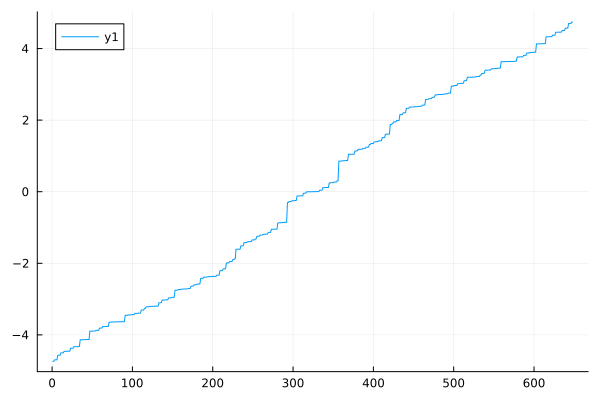

In [4]:
plot(sort(st["spectrum"]))

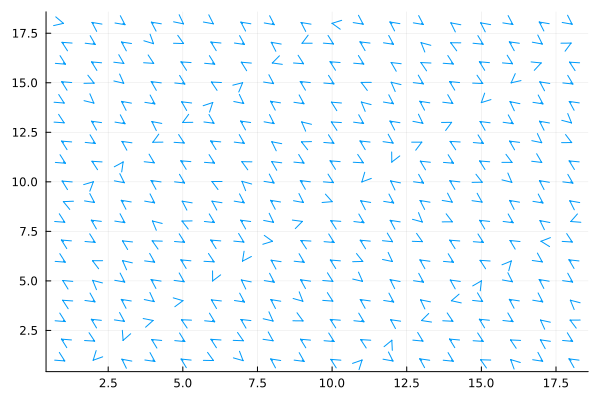

In [5]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(vec(dis_x),vec(dis_y)))




In [6]:
#savefig(p1,"quiverplot.png")

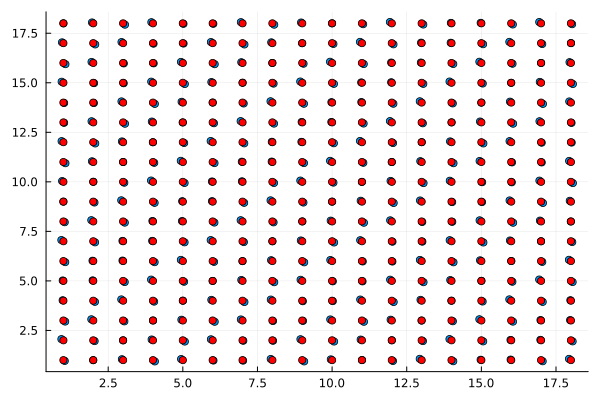

In [7]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [8]:
#savefig(p2,"atomplot.png")

In [9]:
sort(vec(dis_y)-vec(atom_y))

324-element Vector{Float64}:
 -0.06763671497102663
 -0.06724883061356124
 -0.06704990946619738
 -0.06695457259847881
 -0.06681344001143241
 -0.0665451159642636
 -0.06654303436227771
 -0.06642386071036555
 -0.0663456483302709
 -0.06585377484891808
  ⋮
  0.06577464338292316
  0.06624372401229195
  0.06668205826214013
  0.06683913503968952
  0.06687248719494931
  0.06697030850059082
  0.06717034633656738
  0.06787518718396512
  0.06808532945348134

In [10]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

324-element Vector{Float64}:
  1.418464212568079
  2.2322012400929427
  2.2624277567936395
  2.8334233689291914
  3.131403706432153
  3.139209916874269
  3.6037861165558396
  3.62234126903332
  4.138368039225082
  4.168458811764052
  ⋮
 23.349695197083577
 23.435758940814964
 23.440384476263525
 24.037857214201814
 24.07569790123521
 24.07571532450146
 24.763469693815498
 24.766028177621934
 25.452595598710488

In [11]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

14.421448603246455

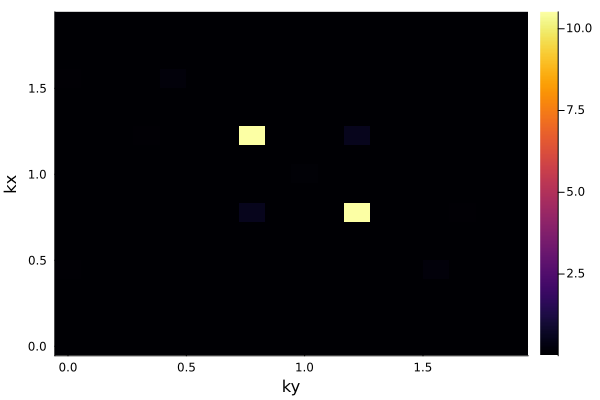

In [12]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [13]:
sort(vec(abs.(Fourier_mode_x)))

324-element Vector{Float64}:
  1.5959455978986625e-16
  1.0207428918827834e-15
  1.0330762564130553e-15
  1.4077978552317947e-15
  1.4574544668247398e-15
  1.4661788101794486e-15
  1.621443163537249e-15
  1.824359185894881e-15
  1.8724613062124e-15
  2.9901867660084754e-15
  ⋮
  0.05933560190558407
  0.05933560190558412
  0.08629500236666811
  0.17153583849997617
  0.17153583849997756
  0.5219538585924626
  0.5219538585924705
 10.518448549826303
 10.51844854982631

In [14]:
findmax(abs.(Fourier_mode_x))

(10.51844854982631, CartesianIndex(8, 12))

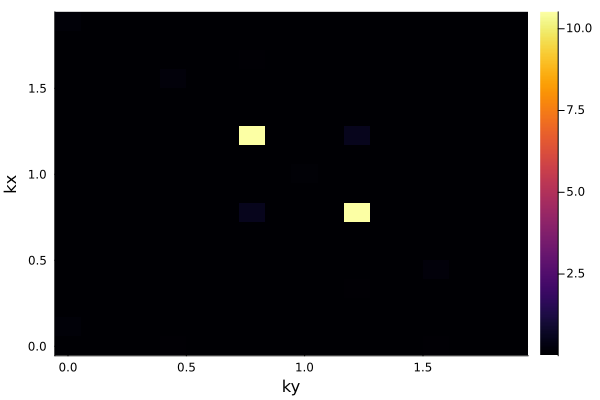

In [15]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [16]:
findmax(abs.(Fourier_mode_y))

(10.518427062304001, CartesianIndex(8, 12))

In [17]:
Fourier_mode_y[8,14]

1.4692036902394512e-5 - 1.8827386115456063e-5im

In [18]:
Fourier_mode_x[8,14]

-8.900827789030952e-5 + 0.00011342265882091221im

In [19]:
Fourier_mode_y[14,8]

-1.295330121615923e-5 - 6.143775229383106e-7im

In [20]:
Fourier_mode_x[14,8]

2.236926698956365e-6 + 9.26161622109553e-8im

In [21]:
Fourier_mode_y[8,8]

-0.3620626343899788 + 0.3759611881983038im

In [22]:
Fourier_mode_x[8,8]

-0.36206240998944417 + 0.37596095777646393im